# Phishing Detection Pipeline
### FYP - Machine Learning Detection Engine

## Cell 1 - Install dependencies

In [28]:
# Run this cell first in colab - installs anything not already in Colab
# !pip install xgboost imbalanced-learn tldextract --quiet
# In Colab, most packages are pre-installed. Locally, install everything.
!pip install -r requirements.txt --quiet


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 2 - Imports

In [29]:
import os
import pandas as pd
import numpy as np
import re
import email
import tldextract
import joblib
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

## Cell 3 - Mount Google Drive
Upload your CSV files to a folder in Drive, e.g. `MyDrive/FYP_Datasets/`

In [30]:
# If running in Google Colab, mount Drive and use the cloud path.
# If running locally, place the CSV files in a folder called 'datasets/'
# in the same directory as this notebook.

try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    DATASET_DIR = '/content/drive/MyDrive/FYP_Datasets/'
    print(f"Running in Colab - datasets at: {DATASET_DIR}")
except ModuleNotFoundError:
    DATASET_DIR = os.path.join(os.getcwd(), 'datasets/')
    print(f"Running locally - datasets at: {DATASET_DIR}")

# Verify the folder exists
assert os.path.isdir(DATASET_DIR), (
    f"Dataset folder not found: {DATASET_DIR}\n"
    f"Please create it and add: Nazario_5.csv, Nigerian_Fraud.csv, "
    f"Enron.csv, SpamAssasin.csv, Ling.csv"
)

Running locally - datasets at: c:\Users\hashm\OneDrive - University of Southampton\1newhampton\0y3\fyp\pynbs\datasets/


## Cell 4 - Load & combine datasets

In [31]:
# Phishing sources (positive class, label=1):
#   - Nazario_5.csv       : phishing rows only (contains all of Nazario.csv)
#   - Nigerian_Fraud.csv  : advance-fee scam emails (100% phishing)
# Legitimate sources (negative class, label=0):
#   - Enron.csv           : label=0 rows only
#                           (label=1 rows in this file are PRODUCT SPAM, not phishing)
#   - SpamAssasin.csv     : label=0 rows only
#                           (label=1 rows are generic spam, not phishing)
#   - Ling.csv            : label=0 rows only
#
# Rationale: the earlier pipeline conflated "product spam" (weight-loss ads,
# electronics promos) with "phishing" (credential theft, financial fraud).
# This version enforces the distinction, keeping only verified phishing in
# the positive class.

def standardise_label(val):
    """Map any label format to 1 (phishing) or 0 (legitimate). NaN = unknown."""
    if pd.isnull(val):
        return np.nan
    v = str(val).strip().lower()
    phishing = {'1', '1.0', 'phishing', 'phish', 'spam', 'fraud', 'scam'}
    legit    = {'0', '0.0', 'ham', 'legitimate', 'legit', 'safe', 'benign'}
    if v in phishing: return 1
    if v in legit:    return 0
    return np.nan


def load_and_filter(filename, keep_label):
    """Load a CSV, standardise labels, and return only rows matching keep_label."""
    try:
        df = pd.read_csv(DATASET_DIR + filename, on_bad_lines='skip')
    except FileNotFoundError:
        print(f'  WARNING: {filename:<22} NOT FOUND — skipping')
        return None

    if 'label' not in df.columns:
        print(f'  WARNING: {filename:<22} has no label column — skipping')
        return None

    df['label'] = df['label'].apply(standardise_label)
    df = df.dropna(subset=['label'])
    df['label'] = df['label'].astype(int)
    df = df[df['label'] == keep_label].copy()

    # Ensure all expected columns exist (some files lack sender/urls)
    for col in ['sender', 'receiver', 'date', 'subject', 'body', 'urls']:
        if col not in df.columns:
            df[col] = ''

    df['__source__'] = filename
    print(f'  {filename:<22} kept {len(df):>6} rows  (label={keep_label})')
    return df[['sender','receiver','date','subject','body','urls','label','__source__']]


phishing_sources = {
    'Nazario_5.csv':      1,
    'Nigerian_Fraud.csv': 1,
}
legitimate_sources = {
    'Enron.csv':       0,
    'SpamAssasin.csv': 0,
    'Ling.csv':        0,
}

print('Loading phishing sources:')
phish_frames = [load_and_filter(f, lbl) for f, lbl in phishing_sources.items()]
print('\nLoading legitimate sources:')
legit_frames = [load_and_filter(f, lbl) for f, lbl in legitimate_sources.items()]

frames = [f for f in (phish_frames + legit_frames) if f is not None]
df_raw = pd.concat(frames, ignore_index=True)

# Deduplicate - same subject + body is almost certainly the same email
before = len(df_raw)
df_raw = df_raw.drop_duplicates(subset=['subject', 'body'], keep='first').reset_index(drop=True)
print(f'\nDeduplication: {before} → {len(df_raw)} rows ({before - len(df_raw)} duplicates removed)')

print(f'\nFinal combined dataset: {df_raw.shape[0]} rows')
print(f'  Phishing   (1): {(df_raw["label"]==1).sum()}')
print(f'  Legitimate (0): {(df_raw["label"]==0).sum()}')
print(f'\nPer-source breakdown:')
print(df_raw.groupby(['__source__', 'label']).size().unstack(fill_value=0))

Loading phishing sources:
  Nazario_5.csv          kept   1565 rows  (label=1)
  Nigerian_Fraud.csv     kept   3332 rows  (label=1)

Loading legitimate sources:
  Enron.csv              kept  15791 rows  (label=0)
  SpamAssasin.csv        kept   4091 rows  (label=0)
  Ling.csv               kept   2401 rows  (label=0)

Deduplication: 27180 → 27180 rows (0 duplicates removed)

Final combined dataset: 27180 rows
  Phishing   (1): 4897
  Legitimate (0): 22283

Per-source breakdown:
label                   0     1
__source__                     
Enron.csv           15791     0
Ling.csv             2401     0
Nazario_5.csv           0  1565
Nigerian_Fraud.csv      0  3332
SpamAssasin.csv      4091     0


## Cell 5 - EDA: Inspect & understand the data

In [32]:
# Preview
display(df_raw.head(3))
print('\nColumn dtypes:')
print(df_raw.dtypes)
print('\nMissing values:')
print(df_raw.isnull().sum())

,sender,receiver,date,subject,body,urls,label,__source__
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1,Nazario_5.csv
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1,Nazario_5.csv
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1,Nazario_5.csv



Column dtypes:
sender           str
receiver         str
date             str
subject          str
body             str
urls          object
label          int64
__source__       str
dtype: object

Missing values:
sender         331
receiver      1583
date           483
subject         96
body             0
urls             0
label            0
__source__       0
dtype: int64


In [33]:
# Check what values are in the label column - they may not be 0/1
print('Unique label values:')
print(df_raw['label'].value_counts())

Unique label values:
label
0    22283
1     4897
Name: count, dtype: int64


## Cell 6 - Feature extraction functions

Three groups of features are extracted:
- **Header features** — sender/domain mismatches, DKIM/SPF presence
- **Body features** — urgency keywords, HTML content, link counts
- **URL features** — suspicious patterns in embedded URLs

In [34]:
import re
import pandas as pd
import numpy as np
import tldextract

# URGENCY KEYWORDS 
URGENCY_WORDS = [
    'verify', 'immediately', 'urgent', 'suspended', 'limited', 'expire',
    'confirm', 'update', 'validate', 'click here', 'act now', 'account locked',
    'unusual activity', 'security alert', 'unauthorised', 'unauthorized',
    'compromised', 'blocked', 'unusual', 'restricted'
]

URL_REGEX = re.compile(r'https?://[^\s<>"\']+')
HTML_TAG_REGEX = re.compile(r'<[^>]+>')

def extract_urls_from_text(text):
    if pd.isnull(text):
        return []
    return URL_REGEX.findall(str(text))


# HEADER FEATURES 
def extract_header_features(row):
    features = {}
    sender   = str(row.get('sender', '')) if not pd.isnull(row.get('sender', np.nan)) else ''
    body_raw = str(row.get('body',   '')) if not pd.isnull(row.get('body',   np.nan)) else ''

    # Sender domain
    sender_domain = ''
    match = re.search(r'@([\w\.-]+)', sender)
    if match:
        sender_domain = match.group(1).lower()

    # Reply-To domain mismatch
    reply_to_match = re.search(r'Reply-To:.*?@([\w\.-]+)', body_raw, re.IGNORECASE)
    reply_domain = reply_to_match.group(1).lower() if reply_to_match else ''
    features['sender_reply_mismatch'] = int(
        bool(sender_domain and reply_domain and sender_domain != reply_domain)
    )

    # SPF / DKIM
    features['has_spf']  = int(bool(re.search(r'spf=pass',  body_raw, re.IGNORECASE)))
    features['has_dkim'] = int(bool(re.search(r'dkim=pass', body_raw, re.IGNORECASE)))

    # Received hops
    features['received_hops'] = len(re.findall(r'^Received:', body_raw, re.MULTILINE))

    # Display name spoofing
    BRAND_DOMAINS = {
        'paypal': 'paypal.com', 'amazon': 'amazon.com', 'apple': 'apple.com',
        'microsoft': 'microsoft.com', 'google': 'google.com',
        'facebook': 'facebook.com', 'netflix': 'netflix.com',
    }
    spoofed = 0
    for brand, legit_domain in BRAND_DOMAINS.items():
        if brand in sender.lower() and legit_domain not in sender_domain:
            spoofed = 1
            break
    features['display_name_spoofed'] = spoofed

    return features


# BODY FEATURES 
def extract_body_features(row):
    features = {}
    body    = str(row.get('body',    '')) if not pd.isnull(row.get('body',    np.nan)) else ''
    subject = str(row.get('subject', '')) if not pd.isnull(row.get('subject', np.nan)) else ''
    full_text = (subject + ' ' + body).lower()

    # Urgency keyword count 
    features['urgency_keyword_count'] = sum(
        full_text.count(kw) for kw in URGENCY_WORDS
    )

    # HTML signals 
    features['has_html'] = int('<html' in body.lower() or '<a href' in body.lower())

    # HTML-to-text ratio: how much of the body is HTML markup vs plain text
    # Phishing emails often have very high HTML ratios (lots of styling, hidden text)
    html_chars = sum(len(tag) for tag in HTML_TAG_REGEX.findall(body))
    total_chars = len(body)
    features['html_to_text_ratio'] = round(html_chars / total_chars, 4) if total_chars > 0 else 0

    # URL signals 
    body_urls = extract_urls_from_text(body)
    features['url_count'] = len(body_urls)

    # Body-URL ratio: what fraction of the body is URL text
    # Phishing emails often have large URLs relative to body text
    url_chars = sum(len(u) for u in body_urls)
    features['body_url_ratio'] = round(url_chars / total_chars, 4) if total_chars > 0 else 0

    # Vocabulary signals 
    # Average word length - phishing emails often use simpler/shorter words
    words = re.findall(r'\b[a-zA-Z]+\b', body)
    features['avg_word_length'] = round(np.mean([len(w) for w in words]), 2) if words else 0

    # Exclamation marks — urgency / emotional manipulation
    features['exclamation_count'] = body.count('!')

    # Credential / financial keywords 
    cred_words = ['password', 'username', 'login', 'sign in', 'credentials', 'ssn', 'credit card']
    features['credential_request'] = int(any(w in full_text for w in cred_words))

    financial_words = ['bank account', 'wire transfer', 'western union', 'inheritance', 'lottery', 'prize']
    features['financial_threat'] = int(any(w in full_text for w in financial_words))

    return features


# URL FEATURES 
def extract_url_features(row):
    features = {
        'url_uses_ip':           0,
        'url_has_at_symbol':     0,
        'url_length':            0,
        'url_dot_count':         0,
        'url_has_https':         0,
        'url_subdomain_depth':   0,
        'url_suspicious_tld':    0,
        # NEW: number of unique external domains
        'external_domain_count': 0,  
    }

    urls_col  = str(row.get('urls', '')) if not pd.isnull(row.get('urls', np.nan)) else ''
    body_urls = extract_urls_from_text(row.get('body', ''))
    col_urls  = extract_urls_from_text(urls_col)
    all_urls  = col_urls + body_urls

    if not all_urls:
        return features

    url = all_urls[0]
    features['url_length']        = len(url)
    features['url_has_at_symbol'] = int('@' in url)
    features['url_has_https']     = int(url.startswith('https'))
    features['url_uses_ip']       = int(bool(
        re.search(r'https?://\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url)
    ))

    try:
        extracted = tldextract.extract(url)
        subdomain = extracted.subdomain
        features['url_subdomain_depth'] = len(subdomain.split('.')) if subdomain else 0
        features['url_dot_count']       = url.count('.')
        suspicious_tlds = {'tk', 'ml', 'ga', 'cf', 'gq', 'xyz', 'top', 'club', 'work'}
        features['url_suspicious_tld']  = int(extracted.suffix in suspicious_tlds)
    except Exception:
        pass

    # Count unique external domains across all URLs in the email
    # Legitimate emails usually link to 1-2 domains; phishing may use many
    unique_domains = set()
    for u in all_urls:
        try:
            ext = tldextract.extract(u)
            if ext.domain:
                unique_domains.add(f'{ext.domain}.{ext.suffix}')
        except Exception:
            pass
    features['external_domain_count'] = len(unique_domains)

    return features

## Cell 7 - Run feature extraction

In [35]:
# Rename the clean label column so the rest of the notebook can use it
df_raw['label_clean'] = df_raw['label']

header_features = df_raw.apply(extract_header_features, axis=1, result_type='expand')
print('  Header features done.')
body_features   = df_raw.apply(extract_body_features,   axis=1, result_type='expand')
print('  Body features done.')
url_features    = df_raw.apply(extract_url_features,    axis=1, result_type='expand')
print('  URL features done.')

df_engineered = pd.concat([header_features, body_features, url_features], axis=1)
df_engineered['label'] = df_raw['label_clean'].values
df_engineered['subject_raw'] = df_raw['subject'].fillna('').astype(str).values
df_engineered['body_raw']    = df_raw['body'].fillna('').astype(str).values

print(f'\nEngineered feature matrix: {df_engineered.shape}')

  Header features done.
  Body features done.
  URL features done.

Engineered feature matrix: (27180, 25)


## Cell 8 - TF-IDF on subject line
Adds text-based features from the subject line, which is a strong phishing signal.

In [36]:
# Cell 8a - THREE-WAY SPLIT (train / val / test) 
from sklearn.model_selection import train_test_split

engineered_cols = [c for c in df_engineered.columns
                   if c not in ['label', 'subject_raw', 'body_raw']]

X_all = df_engineered[engineered_cols + ['subject_raw', 'body_raw']]
y_all = df_engineered['label']

# First: peel off the FINAL test set (20%) and lock it away.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=42, stratify=y_all
)

# Second: split trainval into train (75%) and val (25%) - overall 60/20/20.
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f'Train: {len(X_train)}   Val: {len(X_val)}   Test: {len(X_test)}')
print(f'Train phishing ratio: {y_train.mean():.3f}')
print(f'Val   phishing ratio: {y_val.mean():.3f}')
print(f'Test  phishing ratio: {y_test.mean():.3f}')

Train: 16308   Val: 5436   Test: 5436
Train phishing ratio: 0.180
Val   phishing ratio: 0.180
Test  phishing ratio: 0.180


In [37]:
# Cell 8b - FIT TF-IDF ON TRAIN TEXT ONLY 
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

DATASET_STOPWORDS = [
    'enron','ect','hou','ena','kaminski','vince','shackleton',
    'shirley','stinson','lokay','cash','daren','farmer',
    'spamassassin','spam','spambayes',
    'monkey','jose','mbox','maildir','ling','linguist',
]
STOP = list(set(list(ENGLISH_STOP_WORDS) + DATASET_STOPWORDS))

def clean_body_for_tfidf(text):
    if pd.isnull(text): return ''
    text = HTML_TAG_REGEX.sub(' ', str(text))
    text = re.sub(r'https?://\S+', ' URL ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.lower()

# Subject TF-IDF - fit on TRAIN ONLY
tfidf_subject = TfidfVectorizer(
    max_features=100, stop_words=STOP, ngram_range=(1,2),
    min_df=0.005, max_df=0.95,
)
tfidf_subject.fit(X_train['subject_raw'])
subject_tfidf_cols = [f'subj_{t}' for t in tfidf_subject.get_feature_names_out()]

# Body TF-IDF - fit on TRAIN ONLY
tfidf_body = TfidfVectorizer(
    max_features=200, stop_words=STOP, ngram_range=(1,2),
    min_df=0.005, max_df=0.95,
)
train_body_clean = X_train['body_raw'].apply(clean_body_for_tfidf)
tfidf_body.fit(train_body_clean)
body_tfidf_cols = [f'body_{t}' for t in tfidf_body.get_feature_names_out()]

print(f'Subject TF-IDF vocabulary: {len(subject_tfidf_cols)} terms (fit on train only)')
print(f'Body    TF-IDF vocabulary: {len(body_tfidf_cols)} terms (fit on train only)')

# Leakage sanity checks
for tag, cols in [('subject', subject_tfidf_cols), ('body', body_tfidf_cols)]:
    leaks = [c for c in cols if any(s in c for s in ['enron','kaminski','spamassassin'])]
    print(f'  {tag} leakage check: {leaks if leaks else "clean"}')

Subject TF-IDF vocabulary: 100 terms (fit on train only)
Body    TF-IDF vocabulary: 200 terms (fit on train only)
  subject leakage check: clean
  body leakage check: clean


In [38]:
# Cell 8c - TRANSFORM ALL SPLITS INTO FINAL FEATURE MATRICES 
def build_feature_matrix(X_split):
    """Transform a split into the final numeric feature matrix."""
    # Engineered features (already numeric)
    eng = X_split[engineered_cols].reset_index(drop=True)

    # Subject TF-IDF
    subj = tfidf_subject.transform(X_split['subject_raw']).toarray()
    subj_df = pd.DataFrame(subj, columns=subject_tfidf_cols)

    # Body TF-IDF
    body_clean = X_split['body_raw'].apply(clean_body_for_tfidf)
    body = tfidf_body.transform(body_clean).toarray()
    body_df = pd.DataFrame(body, columns=body_tfidf_cols)

    out = pd.concat([eng, subj_df, body_df], axis=1).fillna(0)
    return out

X_train_mat = build_feature_matrix(X_train)
X_val_mat   = build_feature_matrix(X_val)
X_test_mat  = build_feature_matrix(X_test)

X_trainval_mat = build_feature_matrix(X_trainval)

FEATURE_COLUMNS = list(X_train_mat.columns)
print(f'Feature matrix shape: train={X_train_mat.shape}  val={X_val_mat.shape}  test={X_test_mat.shape}')
print(f'Total features: {len(FEATURE_COLUMNS)}')

Feature matrix shape: train=(16308, 322)  val=(5436, 322)  test=(5436, 322)
Total features: 322


## Cell 9 - Train/test split & handle class imbalance

In [39]:
# Cell 9 - SMOTE on TRAIN only 
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_mat, y_train)

print(f'Before SMOTE - Legit: {(y_train==0).sum()}  Phish: {(y_train==1).sum()}')
print(f'After  SMOTE - Legit: {(y_train_bal==0).sum()}  Phish: {(y_train_bal==1).sum()}')

Before SMOTE - Legit: 13369  Phish: 2939
After  SMOTE - Legit: 13369  Phish: 13369


## Cell 10 - Train models

In [40]:
# Cell 10 - Train models, EVALUATE ON VALIDATION SET 
# NOTE: the test set is not touched here. All model selection happens on val.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0),
}

val_results = {}
for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_bal, y_train_bal)
    y_pred  = model.predict(X_val_mat)
    y_proba = model.predict_proba(X_val_mat)[:, 1]
    val_results[name] = {
        'model':    model,
        'accuracy': accuracy_score(y_val, y_pred),
        'roc_auc':  roc_auc_score(y_val, y_proba),
        'f1':       f1_score(y_val, y_pred),
        'report':   classification_report(y_val, y_pred, target_names=['Legit','Phish']),
        'y_pred':   y_pred,
    }
    print(f'  VAL  Acc={val_results[name]["accuracy"]:.4f}  '
          f'F1={val_results[name]["f1"]:.4f}  ROC-AUC={val_results[name]["roc_auc"]:.4f}')

Training Logistic Regression...
  VAL  Acc=0.9858  F1=0.9611  ROC-AUC=0.9981
Training Random Forest...
  VAL  Acc=0.9877  F1=0.9654  ROC-AUC=0.9959
Training XGBoost...
  VAL  Acc=0.9912  F1=0.9754  ROC-AUC=0.9990


## Cell 11 - Full evaluation report

═══ Logistic Regression ═══
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      4457
       Phish       0.95      0.97      0.96       979

    accuracy                           0.99      5436
   macro avg       0.97      0.98      0.98      5436
weighted avg       0.99      0.99      0.99      5436

═══ Random Forest ═══
              precision    recall  f1-score   support

       Legit       0.99      0.99      0.99      4457
       Phish       0.97      0.96      0.97       979

    accuracy                           0.99      5436
   macro avg       0.98      0.98      0.98      5436
weighted avg       0.99      0.99      0.99      5436

═══ XGBoost ═══
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      4457
       Phish       0.98      0.97      0.98       979

    accuracy                           0.99      5436
   macro avg       0.99      0.98      0.99      5436
weighted

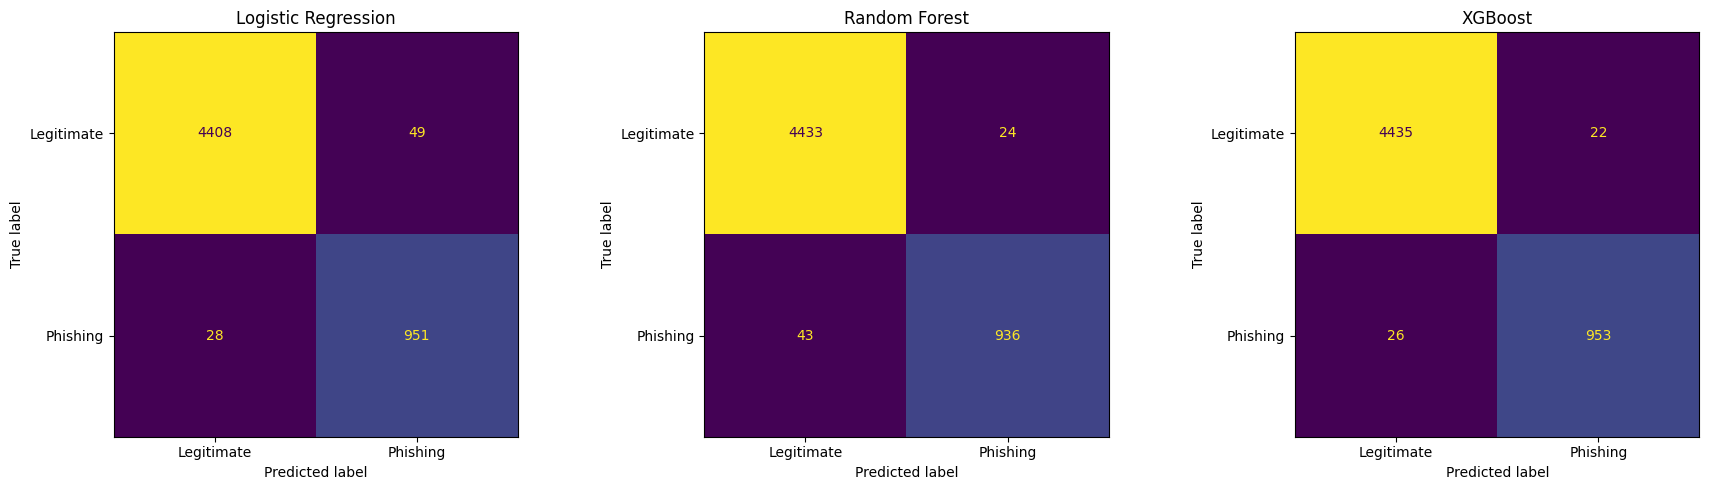

In [41]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5))

for i, (name, res) in enumerate(val_results.items()):
    print(f'═══ {name} ═══')
    print(res['report'])

    # Confusion matrix
    cm = confusion_matrix(y_val, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legitimate', 'Phishing'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

## Cell 12 - Summary comparison table

In [42]:
from sklearn.metrics import precision_score, recall_score, f1_score

summary_rows = []
for name, res in val_results.items():
    y_pred = res['y_pred']
    summary_rows.append({
        'Model':     name,
        'Accuracy':  f"{res['accuracy']:.4f}",
        'Precision': f"{precision_score(y_val, y_pred):.4f}",
        'Recall':    f"{recall_score(y_val, y_pred):.4f}",
        'F1-Score':  f"{f1_score(y_val, y_pred):.4f}",
        'ROC-AUC':   f"{res['roc_auc']:.4f}",
    })

df_summary = pd.DataFrame(summary_rows)
display(df_summary)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9858,0.9510,0.9714,0.9611,0.9981
1,Random Forest,0.9877,0.9750,0.9561,0.9654,0.9959
2,XGBoost,0.9912,0.9774,0.9734,0.9754,0.9990


## Cell 13 - Feature importance (Random Forest)
This drives the 'Why is this suspicious?' explanations.

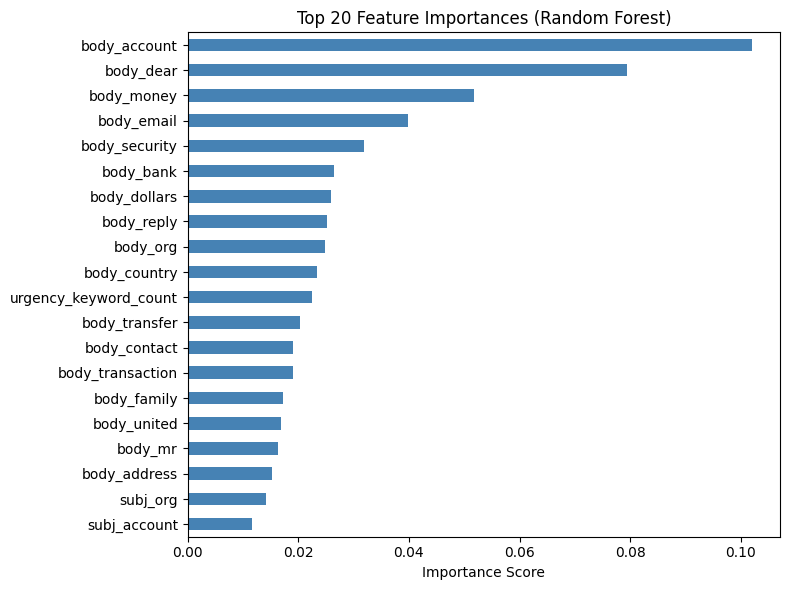


Top 10 features:
  body_account                        0.1020
  body_dear                           0.0794
  body_money                          0.0519
  body_email                          0.0398
  body_security                       0.0320
  body_bank                           0.0264
  body_dollars                        0.0259
  body_reply                          0.0251
  body_org                            0.0248
  body_country                        0.0233


In [43]:
rf_model = val_results['Random Forest']['model']

# Get top 20 most important features
importances = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLUMNS
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Feature Importances (Random Forest)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
for feat, score in importances.head(10).items():
    print(f'  {feat:<35} {score:.4f}')

## Cell 14 - Cross Validation
5-fold cross-validation on Random Forest

In [44]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    val_results['Random Forest']['model'],
    X_trainval_mat, y_trainval,   # CV on trainval only - test set stays sealed
    cv=5, scoring='f1', n_jobs=-1,
)
print(f"F1 per fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean F1: {cv_scores.mean():.4f}  ± {cv_scores.std():.4f}")

F1 per fold: ['0.9543', '0.9687', '0.9634', '0.9683', '0.9573']
Mean F1: 0.9624  ± 0.0058


## Cell 15 - RandomizedSearchCV

In [45]:
# Cell 15 - RandomizedSearchCV on TRAINVAL only (test set untouched) 
from sklearn.model_selection import RandomizedSearchCV

# Rebuild a balanced trainval set for tuning
# X_trainval_mat = build_feature_matrix(X_trainval)
X_trainval_bal, y_trainval_bal = SMOTE(random_state=42).fit_resample(X_trainval_mat, y_trainval)

param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10, cv=3, scoring='f1', n_jobs=-1,
    random_state=42, verbose=1,
)
search.fit(X_trainval_bal, y_trainval_bal)

print(f'\nBest params:  {search.best_params_}')
print(f'Best CV F1:   {search.best_score_:.4f}')

BEST_ESTIMATOR = search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best params:  {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1:   0.9895


═══ FINAL TEST SET PERFORMANCE ═══
              precision    recall  f1-score   support

  Legitimate       0.99      0.99      0.99      4457
    Phishing       0.98      0.97      0.97       979

    accuracy                           0.99      5436
   macro avg       0.98      0.98      0.98      5436
weighted avg       0.99      0.99      0.99      5436

Accuracy : 0.9893
Precision: 0.9752
Recall   : 0.9653
F1-Score : 0.9702
ROC-AUC  : 0.9977


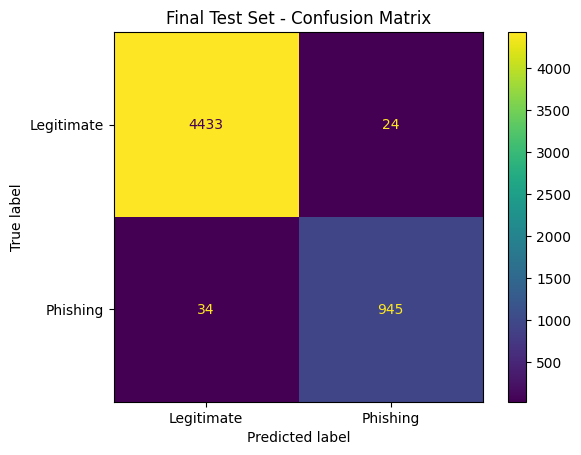

In [46]:
#  FINAL TEST SET EVALUATION 

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score)

y_test_pred  = BEST_ESTIMATOR.predict(X_test_mat)
y_test_proba = BEST_ESTIMATOR.predict_proba(X_test_mat)[:, 1]

print('═══ FINAL TEST SET PERFORMANCE ═══')
print(classification_report(y_test, y_test_pred, target_names=['Legitimate','Phishing']))
print(f'Accuracy : {accuracy_score(y_test, y_test_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_test_pred):.4f}')
print(f'Recall   : {recall_score(y_test, y_test_pred):.4f}')
print(f'F1-Score : {f1_score(y_test, y_test_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_test_proba):.4f}')

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Legitimate','Phishing']).plot()
plt.title('Final Test Set - Confusion Matrix')
plt.show()

## Cell 16 - Export best model for Flask backend

This saves the trained model and TF-IDF vectorizer to Drive.
Flask app can then load these with `joblib.load()`.

In [47]:
# Save the tuned model + both vectorizers + feature column order
joblib.dump(BEST_ESTIMATOR,  DATASET_DIR + 'phishing_model.pkl')
joblib.dump(tfidf_subject,   DATASET_DIR + 'tfidf_subject.pkl')
joblib.dump(tfidf_body,      DATASET_DIR + 'tfidf_body.pkl')
joblib.dump(FEATURE_COLUMNS, DATASET_DIR + 'feature_names.pkl')
print('Saved: phishing_model.pkl, tfidf_subject.pkl, tfidf_body.pkl, feature_names.pkl')

Saved: phishing_model.pkl, tfidf_subject.pkl, tfidf_body.pkl, feature_names.pkl


## Cell 17 - Manual test cases

In [48]:
def predict_email(sender='', subject='', body='', urls=''):
    """
    Single source of truth for inference. Mirrors the training pipeline exactly.
    This is the function your Flask /analyse endpoint should call.
    """
    row = {'sender': sender, 'subject': subject, 'body': body, 'urls': urls}

    # Engineered features (same functions used in training)
    feats = {}
    feats.update(extract_header_features(row))
    feats.update(extract_body_features(row))
    feats.update(extract_url_features(row))

    # Subject TF-IDF
    subj_vec = tfidf_subject.transform([subject]).toarray()[0]
    for col, val in zip(subject_tfidf_cols, subj_vec):
        feats[col] = val

    # Body TF-IDF
    body_vec = tfidf_body.transform([clean_body_for_tfidf(body)]).toarray()[0]
    for col, val in zip(body_tfidf_cols, body_vec):
        feats[col] = val

    # Align with training column order
    x = pd.Series(feats).reindex(FEATURE_COLUMNS).fillna(0).values.reshape(1, -1)

    pred  = int(BEST_ESTIMATOR.predict(x)[0])
    proba = float(BEST_ESTIMATOR.predict_proba(x)[0][1])
    verdict = 'PHISHING' if pred == 1 else 'LEGITIMATE'

    # Top contributing engineered features 
    active = {k: v for k, v in feats.items()
              if v and not k.startswith(('subj_','body_'))}

    print(f'Verdict:    {verdict}')
    print(f'Confidence: {proba:.2%} phishing probability')
    print(f'Active engineered signals: {active}')
    return {'verdict': verdict, 'phishing_probability': proba, 'signals': active}


# Quick sanity checks
print('=== TEST 1: Obvious phishing ===')
predict_email(
    sender='"PayPal" <no-reply@paypa1-secure.tk>',
    subject='URGENT: Your account has been suspended — verify immediately',
    body='Dear customer, your PayPal account has been compromised. '
         'Click here to verify: http://62.14.22.1/login.php',
    urls='http://62.14.22.1/login.php',
)
print('\n=== TEST 2: Legitimate ===')
predict_email(
    sender='alice@company.com',
    subject='Meeting notes from Tuesday',
    body='Hi team, please find attached the notes from our Tuesday meeting. Thanks, Alice.',
)

=== TEST 1: Obvious phishing ===
Verdict:    PHISHING
Confidence: 95.15% phishing probability
Active engineered signals: {'display_name_spoofed': 1, 'urgency_keyword_count': 7, 'url_count': 1, 'avg_word_length': np.float64(5.07), 'credential_request': 1, 'url_uses_ip': 1, 'url_length': 27, 'url_dot_count': 4, 'external_domain_count': 1}

=== TEST 2: Legitimate ===
Verdict:    LEGITIMATE
Confidence: 1.27% phishing probability
Active engineered signals: {'avg_word_length': np.float64(4.92)}


{'verdict': 'LEGITIMATE',
 'phishing_probability': 0.01270688458852541,
 'signals': {'avg_word_length': np.float64(4.92)}}